> **Disclaimer & Collaborative Context**
> This document and its accompanying implementations reflect an independent engineering and theoretical framework developed by the user. The architecture—specifically combining dictionary-based Interacting Multiple Model (IMM) baseline regimes ($F_1$), kinematic velocity delta transition dictionaries ($G_1$), latched pre-fault memory anchoring, and multi-directional hypothesis scanning via Chi-squared Mahalanobis distance gating—was conceptualized, engineered, and refined by the user.
> The role of the Large Language Model (LLM) in this project was strictly collaborative and supportive: acting as a computational assistant to translate theoretical concepts into executable Python code, structure mathematical documentation, and generate visualizations based entirely on the user's explicit design specifications and architectural direction.

# Mathematical Overview & Architecture Documentation

## 1. Introduction & Core Paradigm

This architecture implements a robust, memory-efficient **Interacting Multiple Model (IMM)** state-space estimator optimized for embedded systems. It bridges spatial probabilistic boundary checking with temporal persistence logic to track physical state transitions across multi-dimensional time series.

Rather than maintaining resource-heavy sliding historical data windows, the model uses recursive state representations, separating static operational regimes from dynamic kinematic transitions.

---

## 2. Spatial State Representation: The Static Regimes ($F_1$)

The system defines operational operating points using static baseline dictionaries. Each regime $k$ represents a multi-dimensional mean vector ($\boldsymbol{\mu}_k$) and a covariance matrix ($\boldsymbol{\Sigma}_k$) spanning $d$ sensor dimensions.

* **State Mean Vector:**

$$\boldsymbol{\mu} \in \mathbb{R}^d$$


* **Covariance Matrix:**

$$\boldsymbol{\Sigma} \in \mathbb{R}^{d \times d}$$



capturing both individual sensor variance ($\sigma^2$) and cross-variable structural relationships.

### The Mahalanobis Distance Metric

To evaluate whether a live sensor vector ($\mathbf{x}_t$) belongs to the active static baseline, the system computes the squared **Mahalanobis Distance** ($D^2$):

$$D^2 = (\mathbf{x}_t - \boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1} (\mathbf{x}_t - \boldsymbol{\mu})$$

### $\chi^2$ Hypothesis Gating

To determine if an anomaly has occurred, the distance score is tested against a critical chi-squared ($\chi^2$) threshold derived from the degrees of freedom ($df = d$) at a chosen confidence interval (e.g., $95\%$):

$$D^2 > \chi^2_{0.95, df=d}$$

* **If $D^2 \le \chi^2_{\text{limit}}$:** The data point matches the static regime baseline.
* **If $D^2 > \chi^2_{\text{limit}}$:** A boundary break or anomaly is signaled, triggering the transition verification layer.

---

## 3. Dynamic Kinematic Gating: The Transition Maps ($G_1$)

When an $F_1$ static baseline is breached, the architecture ignores absolute sensor values and evaluates the **first-order derivative vector** ($\Delta \mathbf{x}$) to verify physical momentum between a latched pre-fault state ($\mathbf{x}_{\text{pre-fault}}$) and the current reading ($\mathbf{x}_t$):

$$\Delta \mathbf{x} = \mathbf{x}_t - \mathbf{x}_{\text{pre-fault}}$$

Each transition pathway from a source state to a target state possesses its own expected kinematic delta mean ($\boldsymbol{\mu}_{\Delta}$) and transition covariance ($\boldsymbol{\Sigma}_{\Delta}$).

The system queries all available transition paths using the Mahalanobis distance formula modified for velocity vectors:

$$D^2_{\Delta} = (\Delta \mathbf{x} - \boldsymbol{\mu}_{\Delta})^T \boldsymbol{\Sigma}_{\Delta}^{-1} (\Delta \mathbf{x} - \boldsymbol{\mu}_{\Delta})$$

The target state yielding the minimum $D^2_{\Delta}$ below the critical limit is selected as the true transition path.

---

## 4. Temporal Persistence & Debouncing Logic

To eliminate false-positive cascades caused by stochastic noise spikes, spatial geometry is coupled with a **temporal counting filter**.

1. **Fault Latching:** The moment an $F_1$ boundary break occurs, the system freezes a reference anchor (`x_pre_fault`) and initiates a persistence counter.
2. **Sequential Verification:** The algorithm requires the fault condition to persist across $N$ consecutive clock ticks (e.g., $N=3$).
3. **State Commitment:** Only after the persistence requirement is satisfied is the $G_1$ multi-directional scan executed, safeguarding the state machine against transient noise.

# From Raw Data to the Chi-Squared Metric: The Mathematical Pipeline

This overview outlines the sequential transformation pipeline that takes raw, multi-dimensional sensor telemetry and maps it into a single scalar Chi-squared metric ($D^2$) for real-time state estimation.

---

## Step 1: The Raw Data Stream ($\mathbf{x}_t$)

At every discrete clock tick $t$, the system samples a vector of physical measurements across $d$ distinct sensor channels (e.g., RPM, Throttle Position, MAP, MAF):


$$\mathbf{x}_t = \begin{bmatrix} x_{1,t} \\ x_{2,t} \\ \vdots \\ x_{d,t} \end{bmatrix} \in \mathbb{R}^d$$

* **The Reality:** Raw sensor data contains physical noise, random stochastic fluctuations, and cross-variable correlations governed by the physical laws of the system.

---

## Step 2: Mean Centering ($\mathbf{x}_t - \boldsymbol{\mu}$)

To evaluate how an incoming data point fits an operational regime, it must be compared against the expected static baseline mean vector ($\boldsymbol{\mu}$) for the active state:


$$\boldsymbol{\mu} = \begin{bmatrix} \mu_1 \\ \mu_2 \\ \vdots \\ \mu_d \end{bmatrix} \in \mathbb{R}^d$$


The raw vector is mean-centered to compute the absolute deviation vector:


$$\mathbf{e}_t = \mathbf{x}_t - \boldsymbol{\mu}$$

* **The Reality:** This shifts the multi-dimensional coordinate space so that the expected baseline mean sits at the exact origin ($0, 0, \dots, 0$).

---

## Step 3: Normalization via Covariance Inversion ($\boldsymbol{\Sigma}^{-1}$)

In a multi-dimensional system, variables are not independent; they scale together (e.g., higher RPM correlates with higher mass airflow). A standard Euclidean distance treats all dimensions equally and ignores these structural relationships.

To account for variance and cross-variable correlation, the deviation vector is multiplied by the inverse of the covariance matrix ($\boldsymbol{\Sigma}^{-1}$):


$$\boldsymbol{\Sigma} \in \mathbb{R}^{d \times d}$$

* **The Transform:** Multiplying by $\boldsymbol{\Sigma}^{-1}$ scales each dimension inversely to its variance and rotates the coordinate axes to align with the natural covariance of the system's physics.

---

## Step 4: Quadratic Form Projection to Scalar ($D^2$)

Finally, the scaled deviation vector is projected back against the un-centered deviation vector via a quadratic dot product, collapsing the multi-dimensional vector into a single scalar value known as the **Mahalanobis Distance squared ($D^2$)**:


$$D^2 = (\mathbf{x}_t - \boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1} (\mathbf{x}_t - \boldsymbol{\mu})$$

* **The Result:** This scalar represents the multi-dimensional "statistical distance" of the data point from the expected regime center, fully accounting for the shape of the data's distribution.

---

## Step 5: The Chi-Squared ($\chi^2$) Threshold Test

To convert this continuous distance metric into a binary classification decision (Healthy vs. Fault/Transition), the scalar $D^2$ is mapped directly to the **Chi-Squared distribution**:

* Mathematically, the squared Mahalanobis distance of a multi-normal distribution strictly follows a Chi-squared distribution where the degrees of freedom ($df$) equal the sensor dimensionality ($d$).
* By querying the inverse cumulative distribution function at a chosen confidence limit (e.g., $95\%$):

$$\chi^2_{\text{limit}} = \chi^2_{0.95, df=d}$$


* **The Decision:** If $D^2 \le \chi^2_{\text{limit}}$, the data belongs to the baseline. If $D^2 > \chi^2_{\text{limit}}$, the statistical probability is low enough to declare a structural boundary break.

# State Identification Overview: The Interacting Multiple Model (IMM) Architecture

This overview details how the architecture transitions from a passive detection framework into an active state-identification engine, using multi-directional hypothesis scanning and temporal logic to map telemetry to discrete operating regimes ($F_1$) via kinematic transitions ($G_1$).

---

## 1. The Operational Regimes ($F_1$) as Baselines

The system views an operating environment not as a continuous spectrum, but as a discrete set of stable regimes (e.g., individual gear states).

* Each regime $k$ defines an expected steady-state operating point via its mean vector $\boldsymbol{\mu}_k$ and static covariance matrix $\boldsymbol{\Sigma}_k$.
* Under normal operating conditions, the active state acts as the sole reference frame, evaluating incoming telemetry $\mathbf{x}_t$ against its own baseline.

---

## 2. Boundary Breach & The Persistence Gate

When an anomaly occurs, the system must distinguish between fleeting stochastic noise and genuine operational shifts.

* **Spatial Trigger:** A boundary breach is signaled when the live Mahalanobis distance exceeds the critical $\chi^2$ limit:

$$D^2 = (\mathbf{x}_t - \boldsymbol{\mu}_{\text{active}})^T \boldsymbol{\Sigma}_{\text{active}}^{-1} (\mathbf{x}_t - \boldsymbol{\mu}_{\text{active}}) > \chi^2_{\text{limit}}$$


* **Temporal Latching:** Upon the initial trigger, the system latches the pre-fault telemetry point ($\mathbf{x}_{\text{pre-fault}}$) and initiates a persistence counter.
* **Debouncing:** The system requires the fault condition to hold across $N$ consecutive clock ticks, filtering out random false-positive spikes before any state-identification logic runs.

---

## 3. Kinematic Vector Generation ($\Delta \mathbf{x}$)

Once the persistence requirement is satisfied, the system stops looking at absolute static values and evaluates physical momentum. It computes the first-order differential vector between the live reading and the latched pre-fault anchor:


$$\Delta \mathbf{x} = \mathbf{x}_t - \mathbf{x}_{\text{pre-fault}}$$

* **The Physics Insight:** This vector captures the transient velocity of the system (e.g., the exact drop in RPM and shift in airflow during a gear change).

---

## 4. Multi-Directional Hypothesis Scanning ($G_1$)

To identify *which* state the system is moving into, the architecture abandons rigid, linear assumptions (such as forcing a strict $+1$ step increment) and runs a parallel hypothesis test across all potential transition paths.

* For every possible target state available in the system, the architecture evaluates the corresponding transition dictionary $G_1$, which holds an expected delta mean ($\boldsymbol{\mu}_{\Delta}$) and transition covariance ($\boldsymbol{\Sigma}_{\Delta}$).
* It computes the transition Mahalanobis distance for every candidate path:

$$D^2_{\Delta, k} = (\Delta \mathbf{x} - \boldsymbol{\mu}_{\Delta, k})^T \boldsymbol{\Sigma}_{\Delta, k}^{-1} (\Delta \mathbf{x} - \boldsymbol{\mu}_{\Delta, k})$$



---

## 5. State Selection and Re-Anchoring

The identification algorithm evaluates all calculated transition distances to find the optimal match:

* **Minimum Distance Selection:** The target state that yields the minimum Mahalanobis distance ($D^2_{\Delta}$) across all available hypotheses is selected as the true destination.
* **Safety Verification:** If that minimum distance falls below the critical threshold ($D^2_{\Delta} \le \chi^2_{\text{limit}}$), the state identification is confirmed.
* **State Transition:** The active system state instantly updates to the newly identified target regime, re-anchoring its baseline parameters to the new $F_1$ mean and resetting the fault counter for continuous real-time tracking.

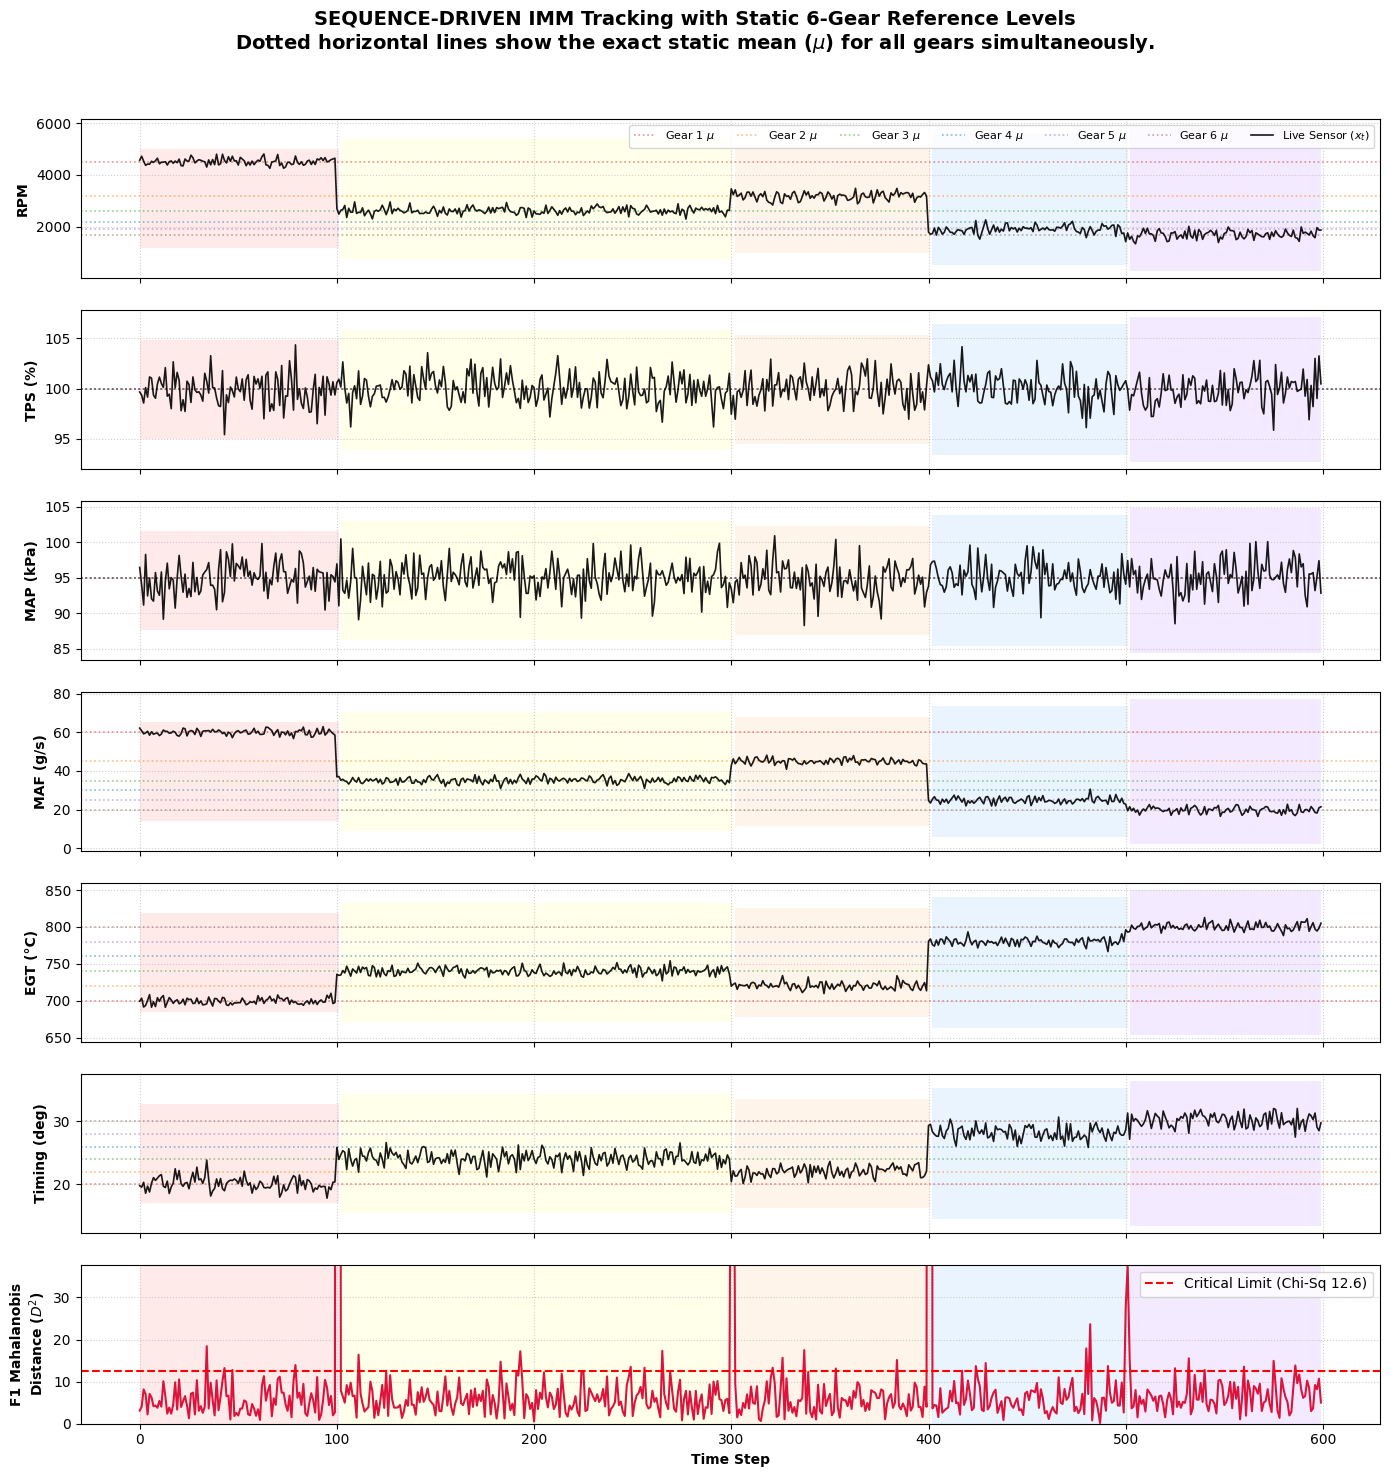

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 1. ARCHITECTURE DEFINITION
# ==========================================
class StateSpaceIMM:
    def __init__(self):
        self.dims = 6  
        self.df = self.dims
        self.chi2_limit = chi2.ppf(0.95, df=self.df)
        
        self.sensor_names = ["RPM", "TPS (%)", "MAP (kPa)", "MAF (g/s)", "EGT (°C)", "Timing (deg)"]
        
        self.F1_states = {}       
        self.G1_transitions = {}  
        
        self._build_dictionaries()
        self.active_state = 1

    def _build_dictionaries(self):
        base_variances = np.array([20000, 2, 5, 2, 20, 1])
        
        f1_means = {
            1: np.array([4500, 100, 95, 60, 700, 20]),
            2: np.array([3200, 100, 95, 45, 720, 22]),
            3: np.array([2600, 100, 95, 35, 740, 24]),
            4: np.array([2200, 100, 95, 30, 760, 26]),
            5: np.array([1900, 100, 95, 25, 780, 28]),
            6: np.array([1700, 100, 95, 20, 800, 30])
        }

        for gear, mean in f1_means.items():
            cov = np.diag(base_variances) + (np.eye(self.dims) * 1e-3)
            self.F1_states[gear] = {
                "mean": mean,
                "cov": cov,
                "inv_cov": np.linalg.inv(cov)
            }

        # Build multi-directional G1 transition dictionaries for any gear pair
        for current_gear in f1_means.keys():
            for target_gear in f1_means.keys():
                if current_gear != target_gear:
                    delta_mean = f1_means[target_gear] - f1_means[current_gear]
                    
                    skip_magnitude = abs(target_gear - current_gear)
                    transition_variances = np.array([50000, 5, 15, 10, 50, 5]) * skip_magnitude
                    
                    cov = np.diag(transition_variances) + (np.eye(self.dims) * 1e-3)
                    self.G1_transitions[(current_gear, target_gear)] = {
                        "mean_delta": delta_mean,
                        "cov": cov,
                        "inv_cov": np.linalg.inv(cov)
                    }

    def evaluate_f1(self, x_t):
        state = self.F1_states[self.active_state]
        deviation = x_t - state["mean"]
        d2 = deviation.T @ state["inv_cov"] @ deviation
        return d2, d2 > self.chi2_limit

    def evaluate_best_transition(self, x_t, x_pre_fault):
        """
        Scans all possible target states to find which transition dictionary 
        fits the live delta vector best (enables dynamic state tracking/skipping).
        """
        delta_x = x_t - x_pre_fault
        best_target = self.active_state
        min_d2 = float('inf')
        best_fault = True
        
        for target_state in self.F1_states.keys():
            if target_state == self.active_state:
                continue
                
            transition_key = (self.active_state, target_state)
            if transition_key in self.G1_transitions:
                transition = self.G1_transitions[transition_key]
                
                deviation = delta_x - transition["mean_delta"]
                d2 = deviation.T @ transition["inv_cov"] @ deviation
                
                if d2 < min_d2:
                    min_d2 = d2
                    best_target = target_state
                    best_fault = d2 > self.chi2_limit
                    
        return best_target, min_d2, best_fault

# ==========================================
# 2. THE SIMULATION LOOP WITH DYNAMIC SCANNING
# ==========================================
def run_simulation(gear_sequence):
    tracker = StateSpaceIMM()
    time_steps = len(gear_sequence)
    
    history_x = np.zeros((time_steps, tracker.dims))
    history_state = np.zeros(time_steps)
    history_f1_score = np.zeros(time_steps)
    
    np.random.seed(42)
    
    x_t_minus_1 = tracker.F1_states[gear_sequence[0]]["mean"]
    tracker.active_state = gear_sequence[0] # Initialize to the first gear in your sequence
    
    fault_counter = 0 
    x_pre_fault = np.zeros(tracker.dims)

    for t in range(time_steps):
        # 1. SIMULATE THE PHYSICAL WORLD USING YOUR PASSED SEQUENCE
        current_true_gear = gear_sequence[t]
            
        true_state = tracker.F1_states[current_true_gear]
        noise = np.random.multivariate_normal(np.zeros(tracker.dims), true_state["cov"])
        x_t = true_state["mean"] + noise
        history_x[t] = x_t

        # 2. THE ALGORITHMIC TRACKING LOOP
        f1_d2, f1_fault = tracker.evaluate_f1(x_t)
        history_f1_score[t] = f1_d2
        
        # We only trigger a fault check if active_state doesn't match reality and we aren't at max limits
        if f1_fault:
            if fault_counter == 0:
                x_pre_fault = x_t_minus_1
                
            fault_counter += 1
            
            if fault_counter >= 3:
                # Dynamically scan all G1 pathways to find the matching state transition
                detected_target, g1_d2, g1_fault = tracker.evaluate_best_transition(x_t, x_pre_fault)
                
                if not g1_fault:
                    tracker.active_state = detected_target
                    fault_counter = 0 
                    
                    f1_d2, _ = tracker.evaluate_f1(x_t)
                    history_f1_score[t] = f1_d2
        else:
            fault_counter = 0

        history_state[t] = tracker.active_state
        x_t_minus_1 = x_t
        
    return history_x, history_state, history_f1_score, tracker

# ==========================================
# 3. VISUALIZATION DASHBOARD WITH STATIC 6-GEAR REFERENCE LINES
# ==========================================
def plot_results(history_x, history_state, history_f1_score, tracker):
    fig, axes = plt.subplots(7, 1, figsize=(14, 16), sharex=True)
    time_axis = np.arange(len(history_state))
    
    colors = ['#ff9999', '#ffcc99', '#ffff99', '#99ff99', '#99ccff', '#cc99ff']
    gear_colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd', '#8c564b']
    
    def apply_state_shading(ax):
        for gear in range(1, 7):
            mask = (history_state == gear)
            if np.any(mask):
                ax.fill_between(time_axis, ax.get_ylim()[0], ax.get_ylim()[1], 
                                where=mask, color=colors[gear-1], alpha=0.2, linewidth=0)

    # Plot the 6 Sensor Dimensions with all 6 static gear mean levels
    for i in range(tracker.dims):
        ax = axes[i]
        
        # Plot all 6 static F1 mean levels across the entire time axis
        for gear_id, state_dict in tracker.F1_states.items():
            mean_val = state_dict["mean"][i]
            ax.axhline(mean_val, color=gear_colors[gear_id - 1], linestyle=':', alpha=0.5, linewidth=1.2,
                       label=f"Gear {gear_id} $\mu$" if i == 0 else "")

        # Plot the live sensor data on top
        ax.plot(time_axis, history_x[:, i], color='black', linewidth=1.2, alpha=0.9, label="Live Sensor ($x_t$)" if i == 0 else "")
        
        ax.set_ylabel(tracker.sensor_names[i], fontweight='bold')
        ax.grid(True, linestyle=':', alpha=0.6)
        apply_state_shading(ax)
        
        if i == 0:
            ax.legend(loc="upper right", fontsize=8, ncol=7)

    # Plot the Mahalanobis Distance (F1 Score)
    ax_chi = axes[6]
    ax_chi.plot(time_axis, history_f1_score, color='crimson', linewidth=1.5)
    ax_chi.axhline(tracker.chi2_limit, color='red', linestyle='--', label=f"Critical Limit (Chi-Sq {tracker.chi2_limit:.1f})")
    ax_chi.set_ylabel("F1 Mahalanobis\nDistance ($D^2$)", fontweight='bold')
    ax_chi.set_xlabel("Time Step", fontweight='bold')
    ax_chi.legend(loc="upper right")
    ax_chi.grid(True, linestyle=':', alpha=0.6)
    
    ax_chi.set_ylim(0, tracker.chi2_limit * 3)
    apply_state_shading(ax_chi)

    plt.suptitle("SEQUENCE-DRIVEN IMM Tracking with Static 6-Gear Reference Levels\n"
                 "Dotted horizontal lines show the exact static mean ($\mu$) for all gears simultaneously.", 
                 fontsize=14, fontweight='bold', y=0.92)
    
    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.subplots_adjust(hspace=0.2)
    plt.show()

if __name__ == "__main__":
    # Build a custom 600-step test sequence (100 ticks per gear phase)
    # This explicitly tests: Normal -> Skip Shift -> Cruising -> Downshift -> Major Jump
    test_sequence = (
        [1] * 100 +  # Gear 1 for 100 ticks
        [3] * 100 +  # Skip straight to Gear 3 for 100 ticks
        [3] * 100 +  # Steady in Gear 3
        [2] * 100 +  # Downshift to Gear 2 for 100 ticks
        [5] * 100 +  # Jump to Gear 5 for 100 ticks
        [6] * 100    # Shift to Gear 6 for final 100 ticks
    )
    
    hist_x, hist_state, hist_f1, model = run_simulation(test_sequence)
    plot_results(hist_x, hist_state, hist_f1, model)

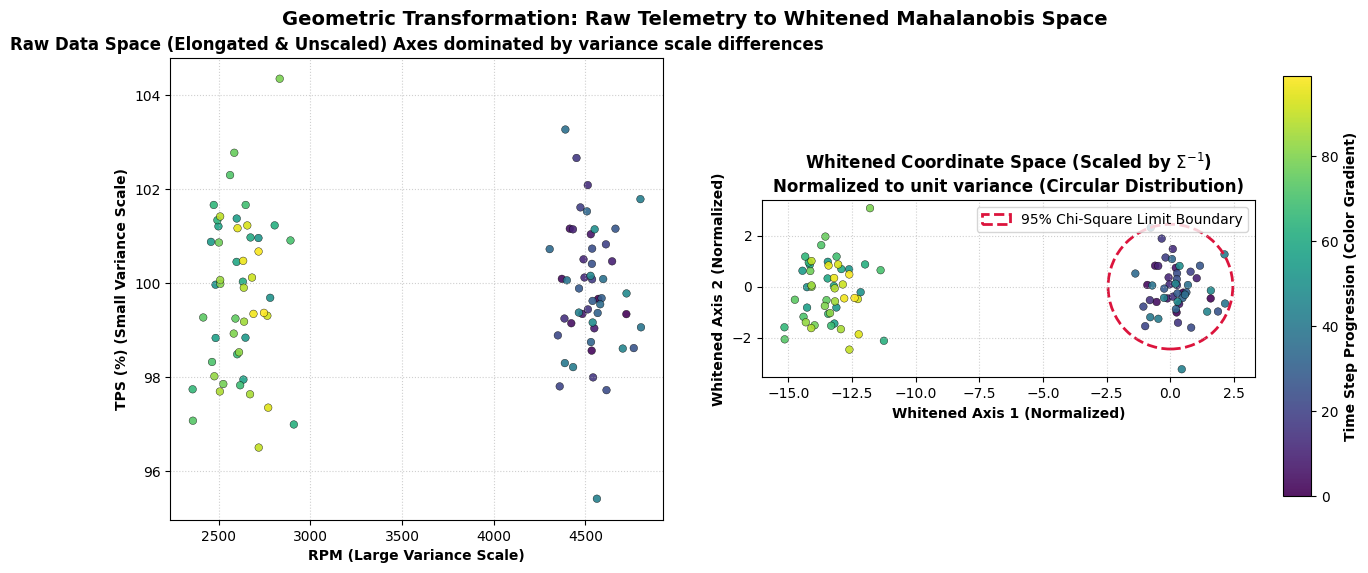

<Figure size 640x480 with 0 Axes>

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. SETUP TEST SEQUENCE & TRANSFORMATIONS
# ==========================================
def run_transformation_comparison():
    # Base configuration matching your IMM model
    dims = 6
    f1_means = {
        1: np.array([4500, 100, 95, 60, 700, 20]),
        2: np.array([3200, 100, 95, 45, 720, 22]),
        3: np.array([2600, 100, 95, 35, 740, 24]),
        4: np.array([2200, 100, 95, 30, 760, 26]),
        5: np.array([1900, 100, 95, 25, 780, 28]),
        6: np.array([1700, 100, 95, 20, 800, 30])
    }
    
    base_variances = np.array([20000, 2, 5, 2, 20, 1])
    cov = np.diag(base_variances) + (np.eye(dims) * 1e-3)
    inv_cov = np.linalg.inv(cov)
    
    # Cholesky factor for whitening transformation (L @ deviation)
    # Sigma^-1 = L^T @ L -> L is lower triangular
    L = np.linalg.cholesky(inv_cov)
    
    # Build a test gear sequence (focusing on Gear 1 to Gear 3 transition for 2D visualization)
    # We will look specifically at Sensor 0 (RPM) vs Sensor 1 (TPS)
    np.random.seed(42)
    gear_sequence = [1] * 50 + [3] * 50
    time_steps = len(gear_sequence)
    
    raw_data = np.zeros((time_steps, dims))
    whitened_data = np.zeros((time_steps, dims))
    
    # Use Gear 1 mean as reference origin for transformation comparison
    mu_ref = f1_means[1]
    
    for t in range(time_steps):
        gear = gear_sequence[t]
        true_mean = f1_means[gear]
        noise = np.random.multivariate_normal(np.zeros(dims), cov)
        x_t = true_mean + noise
        raw_data[t] = x_t
        
        # Transform: Whitening via Cholesky factor and de-meaning relative to Gear 1 baseline
        deviation = x_t - mu_ref
        whitened_data[t] = L @ deviation

    return raw_data, whitened_data, time_steps

# ==========================================
# 2. PLOTTING RAW VS WHITENED SPACE
# ==========================================
def plot_space_transformation(raw_data, whitened_data, time_steps):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    time_colors = np.arange(time_steps)
    
    # Focus on Dimension 0 (RPM) vs Dimension 1 (TPS) for clear 2D projection
    dim_x, dim_y = 0, 1
    
    # --- PLOT 1: RAW DATA SPACE (Elliptical / Skewed) ---
    ax1 = axes[0]
    sc1 = ax1.scatter(raw_data[:, dim_x], raw_data[:, dim_y], 
                      c=time_colors, cmap='viridis', s=30, edgecolor='k', linewidth=0.3, alpha=0.9)
    ax1.set_title("Raw Data Space (Elongated & Unscaled) Axes dominated by variance scale differences", fontweight='bold')
    ax1.set_xlabel("RPM (Large Variance Scale)", fontweight='bold')
    ax1.set_ylabel("TPS (%) (Small Variance Scale)", fontweight='bold')
    ax1.grid(True, linestyle=':', alpha=0.6)
    
    # --- PLOT 2: WHITENED / MAHALANOBIS SPACE (Symmetric Hypersphere) ---
    ax2 = axes[1]
    sc2 = ax2.scatter(whitened_data[:, dim_x], whitened_data[:, dim_y], 
                      c=time_colors, cmap='viridis', s=30, edgecolor='k', linewidth=0.3, alpha=0.9)
    ax2.set_title("Whitened Coordinate Space (Scaled by $\Sigma^{-1}$)\nNormalized to unit variance (Circular Distribution)", fontweight='bold')
    ax2.set_xlabel("Whitened Axis 1 (Normalized)", fontweight='bold')
    ax2.set_ylabel("Whitened Axis 2 (Normalized)", fontweight='bold')
    ax2.grid(True, linestyle=':', alpha=0.6)
    
    # Draw a reference Chi-Square radius circle in whitened space
    # For df=2 at 95% confidence, chi2 limit ~ 5.99 -> radius = sqrt(5.99) ~ 2.45
    chi2_radius = np.sqrt(5.99)
    circle = plt.Circle((0, 0), chi2_radius, color='crimson', fill=False, linestyle='--', linewidth=2, label="95% Chi-Square Limit Boundary")
    ax2.add_patch(circle)
    ax2.legend(loc="upper right")
    
    # Equal aspect ratio for true geometric representation in whitened space
    ax2.set_aspect('equal', adjustable='box')

    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(sc2, cax=cbar_ax)
    cbar.set_label("Time Step Progression (Color Gradient)", fontweight='bold')

    plt.suptitle("Geometric Transformation: Raw Telemetry to Whitened Mahalanobis Space", fontsize=14, fontweight='bold', y=0.96)
    plt.show()
    plt.tight_layout()

if __name__ == "__main__":
    raw, whitened, steps = run_transformation_comparison()
    plot_space_transformation(raw, whitened, steps)

## 1. Reference Material: Normal to Chi-Squared & Distance Formula

The mathematical foundation mapping multi-dimensional normal distributions to a scalar Chi-squared metric via Mahalanobis distance is well-documented in multivariate statistics and quality control theory:

* **The Mahalanobis Distance Formula & Covariance Inversion:**
Given a random observation vector $\mathbf{x}$ from a multivariate distribution with mean vector $\boldsymbol{\mu}$ and covariance matrix $\boldsymbol{\Sigma}$, the squared Mahalanobis distance ($D^2$) is defined as:

$$D^2 = (\mathbf{x} - \boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu})$$



This quadratic form scales and de-correlates the variables, acting as a multivariate extension of standard univariate z-score normalization ($z = \frac{x - \mu}{\sigma}$).
* **The Chi-Squared Distribution Mapping:**
By statistical theorem, if an $n$-dimensional random vector follows a multivariate normal distribution $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, its squared Mahalanobis distance strictly follows a Chi-squared distribution ($\chi^2$) with $n$ degrees of freedom:

$$D^2 \sim \chi^2_n$$



Consequently, comparing the calculated $D^2$ score against the inverse cumulative distribution function (quantile) of the Chi-squared distribution at a given confidence limit (such as $95\%$ or $\alpha = 0.05$) provides an exact statistical boundary for outlier or anomaly detection.
* **Academic and Textual Sources:**
* **Mardia, K. V., Kent, J. T., & Bibby, J. (1979):** *Multivariate Analysis* (Academic Press) — establishes the foundational distribution theorem relating population Mahalanobis squared distances to Chi-squared random variables.
* **Hotelling, H. (1931):** *The Generalization of Student's Ratio* (Annals of Mathematical Statistics) — foundational work introducing generalized multivariate distance measures and quadratic forms for statistical testing.



---

## 2. Contextual Support for Engine Telemetry Parameters (RPM, TPS, MAP, etc.)

Using physical engine variables—such as Revolutions Per Minute (**RPM**), Throttle Position Sensor (**TPS**), Manifold Absolute Pressure (**MAP**), Mass Airflow (**MAF**), Exhaust Gas Temperature (**EGT**), and Ignition Timing—as vector dimensions for multi-state tracking is standard practice in automotive engineering and Multivariate Statistical Process Control (MSPC):

* **Multivariate Engine Behavior:** Internal combustion parameters are fundamentally interdependent; for instance, a change in throttle position (TPS) instantaneously forces shifts in manifold pressure (MAP), airflow (MAF), and engine speed (RPM) governed by thermodynamic and mechanical laws.
* **Industrial and Automotive Precedent:** Engine Control Units (ECUs) and virtual sensor frameworks utilize multi-sensor state spaces because single-sensor thresholds fail to capture coupled system degradation. Monitoring these specific variables via covariance matrices allows systems to detect mechanical anomalies (such as misfires, transmission slip, or structural shifts) while ignoring normal cross-variable covariation.

https://statproofbook.github.io/P/mvn-chi2.html
### Summary of the Proof

1. **The Quadratic Form Statement:**
Given an $n$-dimensional random vector $X$ following a multivariate normal distribution with mean $\mathbf{0}$ and covariance matrix $\mathbf{\Sigma}$ ($X \sim \mathcal{N}(0, \mathbf{\Sigma})$), its weighted quadratic form follows a Chi-squared distribution with $n$ degrees of freedom:

$$Y = X^T \mathbf{\Sigma}^{-1} X \sim \chi^2(n)$$

2. **The Whitening Step ($Z = \mathbf{\Sigma}^{-1/2}X$):**
By applying the matrix square root of the inverse covariance matrix, the random vector is projected into a transformed coordinate space ($Z$). Through the linear transformation theorem, $Z$ simplifies to a standard multivariate normal distribution:

$$Z \sim \mathcal{N}(0, \mathbf{I}_n)$$

where every individual element $Z_i$ is an independent, standard normal variable ($Z_i \sim \mathcal{N}(0,1)$).
3. **Reduction to Sum of Squares:**
Expanding the quadratic form in terms of $Z$ gives:

$$Y = X^T \mathbf{\Sigma}^{-1} X = (X^T \mathbf{\Sigma}^{-1/2}) (\mathbf{\Sigma}^{-1/2} X) = Z^T Z = \sum_{i=1}^{n} Z_i^2$$

Because $Y$ is the sum of $n$ squared independent standard normal variables, by definition it strictly follows the Chi-squared distribution $\chi^2(n)$.

---

### Direct Tie to the 8D Configuration

This proof mathematically guarantees the threshold logic used in this configuration:

* When evaluating the 8-dimensional telemetry vectors ($n = 8$), computing the squared Mahalanobis distance $D^2 = e_t^T \mathbf{\Sigma}^{-1} e_t$ reduces all 8 physical sensor channels (RPM, TPS, MAP, MAF, EGT, Timing, Torque, Lambda) down to a single sum of independent squared standard normal variables $Z_1^2 + Z_2^2 + \dots + Z_8^2$.
* This allows the system to set a single scalar cutoff—such as $\chi^2(8) = 15.51$ for a 95% confidence limit—to detect whether the entire 8-dimensional operational regime has shifted or experienced an anomaly.

Reference: Introduction to Bayesian Statistics (2nd Edition, 2007) by Karl-Rudolf Koch (Publisher: Springer).

Specific Section: Chapter 2.4.5 (Chi-Squared Distribution, pp. 48–49, equation 2.180), which formally derives the proof mapping multivariate normal quadratic forms to Chi-squared distributions.

Reference: Mahalanobis, P. C. (1936). On the generalised distance in statistics. Proceedings of the National Institute of Sciences of India, 2(1), 49–55.

 STATE SEQUENCE MATCH EVALUATION
Total Steps Evaluated: 600
Overall State Match Accuracy: 98.67%
Mismatches detected at 8 time steps.
First divergence point at step: 100


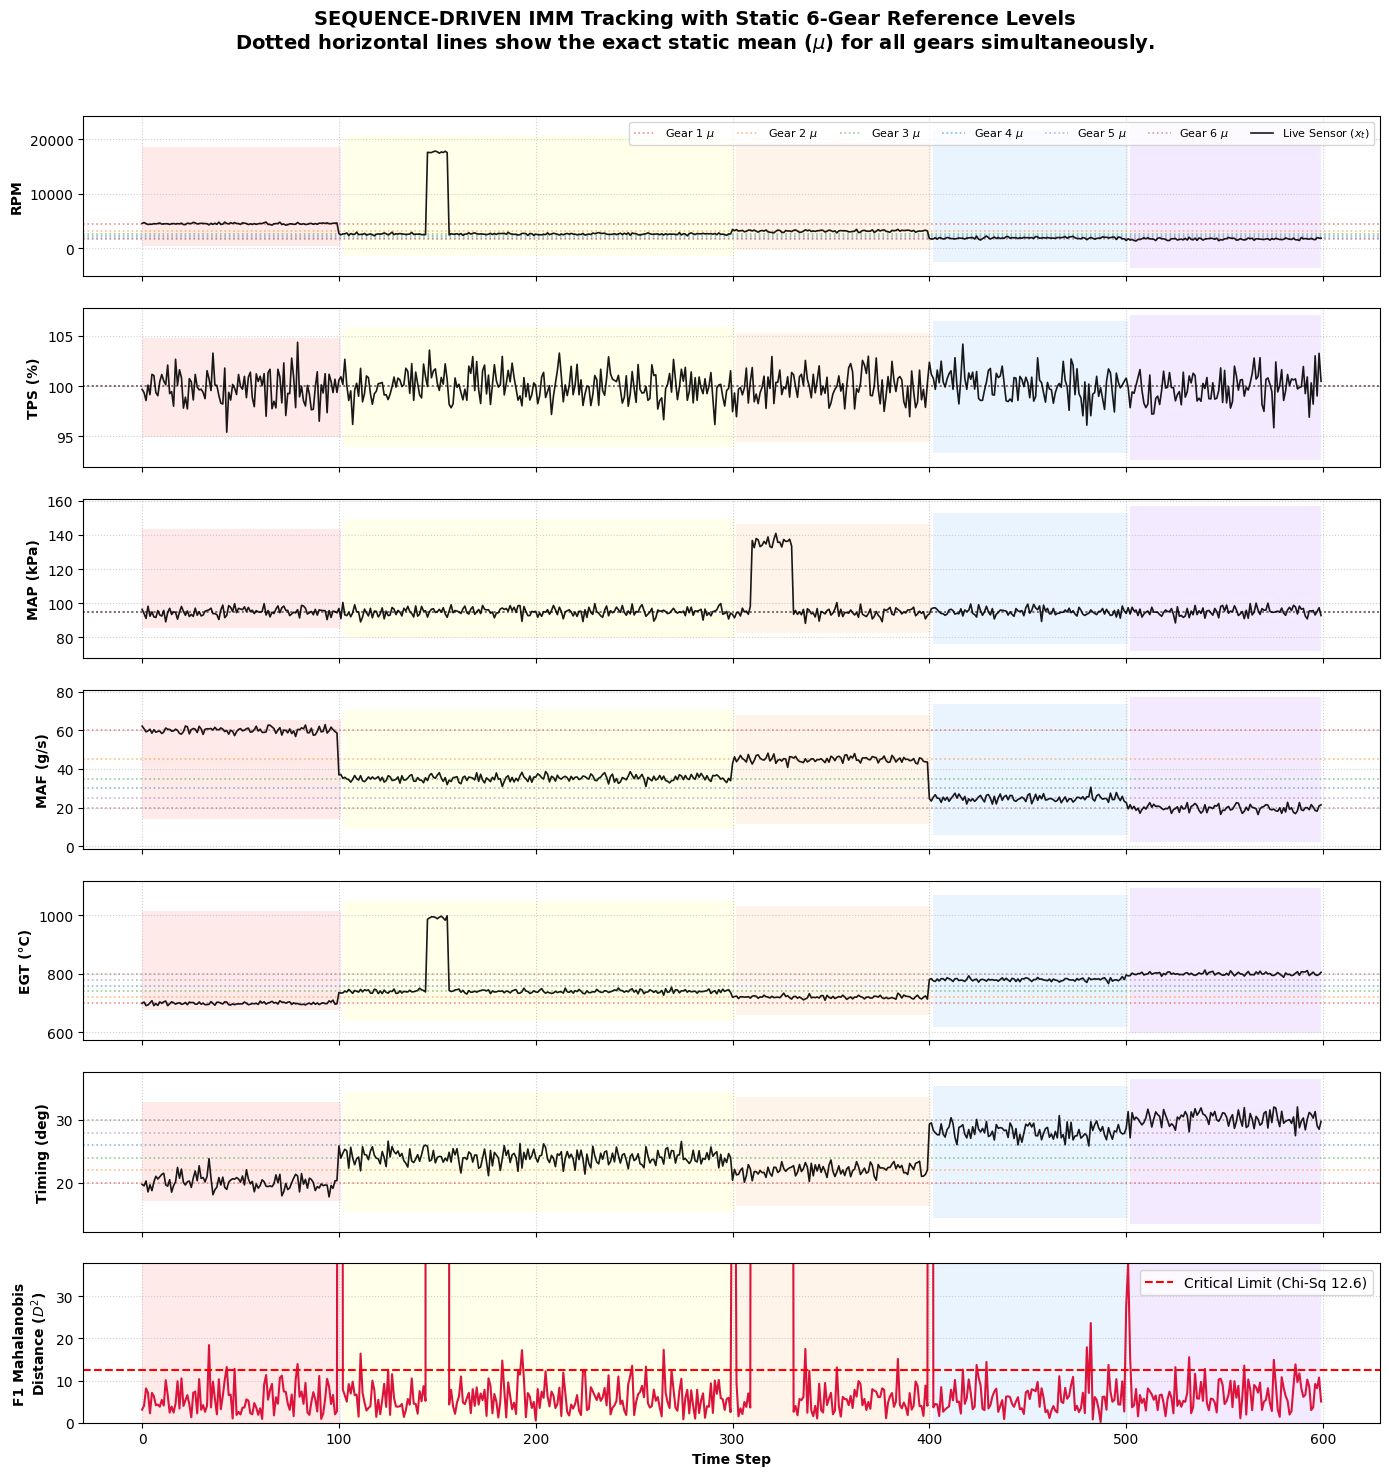

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 1. ARCHITECTURE DEFINITION
# ==========================================
class StateSpaceIMM:
    def __init__(self):
        self.dims = 6  
        self.df = self.dims
        self.chi2_limit = chi2.ppf(0.95, df=self.df)
        
        self.sensor_names = ["RPM", "TPS (%)", "MAP (kPa)", "MAF (g/s)", "EGT (°C)", "Timing (deg)"]
        
        self.F1_states = {}       
        self.G1_transitions = {}  
        
        self._build_dictionaries()
        self.active_state = 1

    def _build_dictionaries(self):
        base_variances = np.array([20000, 2, 5, 2, 20, 1])
        
        f1_means = {
            1: np.array([4500, 100, 95, 60, 700, 20]),
            2: np.array([3200, 100, 95, 45, 720, 22]),
            3: np.array([2600, 100, 95, 35, 740, 24]),
            4: np.array([2200, 100, 95, 30, 760, 26]),
            5: np.array([1900, 100, 95, 25, 780, 28]),
            6: np.array([1700, 100, 95, 20, 800, 30])
        }

        for gear, mean in f1_means.items():
            cov = np.diag(base_variances) + (np.eye(self.dims) * 1e-3)
            self.F1_states[gear] = {
                "mean": mean,
                "cov": cov,
                "inv_cov": np.linalg.inv(cov)
            }

        # Build multi-directional G1 transition dictionaries for any gear pair
        for current_gear in f1_means.keys():
            for target_gear in f1_means.keys():
                if current_gear != target_gear:
                    delta_mean = f1_means[target_gear] - f1_means[current_gear]
                    
                    skip_magnitude = abs(target_gear - current_gear)
                    transition_variances = np.array([50000, 5, 15, 10, 50, 5]) * skip_magnitude
                    
                    cov = np.diag(transition_variances) + (np.eye(self.dims) * 1e-3)
                    self.G1_transitions[(current_gear, target_gear)] = {
                        "mean_delta": delta_mean,
                        "cov": cov,
                        "inv_cov": np.linalg.inv(cov)
                    }

    def evaluate_f1(self, x_t):
        state = self.F1_states[self.active_state]
        deviation = x_t - state["mean"]
        d2 = deviation.T @ state["inv_cov"] @ deviation
        return d2, d2 > self.chi2_limit

    def evaluate_best_transition(self, x_t, x_pre_fault):
        """
        Scans all possible target states to find which transition dictionary 
        fits the live delta vector best (enables dynamic state tracking/skipping).
        """
        delta_x = x_t - x_pre_fault
        best_target = self.active_state
        min_d2 = float('inf')
        best_fault = True
        
        for target_state in self.F1_states.keys():
            if target_state == self.active_state:
                continue
                
            transition_key = (self.active_state, target_state)
            if transition_key in self.G1_transitions:
                transition = self.G1_transitions[transition_key]
                
                deviation = delta_x - transition["mean_delta"]
                d2 = deviation.T @ transition["inv_cov"] @ deviation
                
                if d2 < min_d2:
                    min_d2 = d2
                    best_target = target_state
                    best_fault = d2 > self.chi2_limit
                    
        return best_target, min_d2, best_fault

# ==========================================
# 2. THE SIMULATION LOOP WITH DYNAMIC SCANNING
# ==========================================
def run_simulation(gear_sequence):
    tracker = StateSpaceIMM()
    time_steps = len(gear_sequence)
    
    history_x = np.zeros((time_steps, tracker.dims))
    history_state = np.zeros(time_steps)
    history_f1_score = np.zeros(time_steps)
    
    np.random.seed(42)
    
    x_t_minus_1 = tracker.F1_states[gear_sequence[0]]["mean"]
    tracker.active_state = gear_sequence[0] # Initialize to the first gear in your sequence
    
    fault_counter = 0 
    x_pre_fault = np.zeros(tracker.dims)

    for t in range(time_steps):
        # 1. SIMULATE THE PHYSICAL WORLD USING YOUR PASSED SEQUENCE
        current_true_gear = gear_sequence[t]
            
        true_state = tracker.F1_states[current_true_gear]
        noise = np.random.multivariate_normal(np.zeros(tracker.dims), true_state["cov"])
        x_t = true_state["mean"] + noise

        # --- MALFUNCTION INJECTION HOOK ---
        # Example 1: Inject a sudden sensor spike during a static state (e.g., around t = 150)
        if 145 <= t <= 155:
            x_t[0] += 15000  # Massive RPM spike anomaly
            x_t[4] += 250    # EGT spike anomaly

        # Example 2: Inject a persistent sensor bias/drift during a transition phase (e.g., around t = 310 to 330)
        elif 310 <= t <= 330:
            x_t[2] += 40     # MAP pressure rail failure
        # ----------------------------------

        history_x[t] = x_t

        # 2. THE ALGORITHMIC TRACKING LOOP
        f1_d2, f1_fault = tracker.evaluate_f1(x_t)
        history_f1_score[t] = f1_d2
        
        # We only trigger a fault check if active_state doesn't match reality and we aren't at max limits
        if f1_fault:
            if fault_counter == 0:
                x_pre_fault = x_t_minus_1
                
            fault_counter += 1
            
            if fault_counter >= 3:
                # Dynamically scan all G1 pathways to find the matching state transition
                detected_target, g1_d2, g1_fault = tracker.evaluate_best_transition(x_t, x_pre_fault)
                
                if not g1_fault:
                    tracker.active_state = detected_target
                    fault_counter = 0 
                    
                    f1_d2, _ = tracker.evaluate_f1(x_t)
                    history_f1_score[t] = f1_d2
        else:
            fault_counter = 0

        history_state[t] = tracker.active_state
        x_t_minus_1 = x_t
        
    return history_x, history_state, history_f1_score, tracker

# ==========================================
# 3. VISUALIZATION DASHBOARD WITH STATIC 6-GEAR REFERENCE LINES
# ==========================================
def plot_results(history_x, history_state, history_f1_score, tracker):
    fig, axes = plt.subplots(7, 1, figsize=(14, 16), sharex=True)
    time_axis = np.arange(len(history_state))
    
    colors = ['#ff9999', '#ffcc99', '#ffff99', '#99ff99', '#99ccff', '#cc99ff']
    gear_colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd', '#8c564b']
    
    def apply_state_shading(ax):
        for gear in range(1, 7):
            mask = (history_state == gear)
            if np.any(mask):
                ax.fill_between(time_axis, ax.get_ylim()[0], ax.get_ylim()[1], 
                                where=mask, color=colors[gear-1], alpha=0.2, linewidth=0)

    # Plot the 6 Sensor Dimensions with all 6 static gear mean levels
    for i in range(tracker.dims):
        ax = axes[i]
        
        # Plot all 6 static F1 mean levels across the entire time axis
        for gear_id, state_dict in tracker.F1_states.items():
            mean_val = state_dict["mean"][i]
            ax.axhline(mean_val, color=gear_colors[gear_id - 1], linestyle=':', alpha=0.5, linewidth=1.2,
                       label=f"Gear {gear_id} $\mu$" if i == 0 else "")

        # Plot the live sensor data on top
        ax.plot(time_axis, history_x[:, i], color='black', linewidth=1.2, alpha=0.9, label="Live Sensor ($x_t$)" if i == 0 else "")
        
        ax.set_ylabel(tracker.sensor_names[i], fontweight='bold')
        ax.grid(True, linestyle=':', alpha=0.6)
        apply_state_shading(ax)
        
        if i == 0:
            ax.legend(loc="upper right", fontsize=8, ncol=7)

    # Plot the Mahalanobis Distance (F1 Score)
    ax_chi = axes[6]
    ax_chi.plot(time_axis, history_f1_score, color='crimson', linewidth=1.5)
    ax_chi.axhline(tracker.chi2_limit, color='red', linestyle='--', label=f"Critical Limit (Chi-Sq {tracker.chi2_limit:.1f})")
    ax_chi.set_ylabel("F1 Mahalanobis\nDistance ($D^2$)", fontweight='bold')
    ax_chi.set_xlabel("Time Step", fontweight='bold')
    ax_chi.legend(loc="upper right")
    ax_chi.grid(True, linestyle=':', alpha=0.6)
    
    ax_chi.set_ylim(0, tracker.chi2_limit * 3)
    apply_state_shading(ax_chi)

    plt.suptitle("SEQUENCE-DRIVEN IMM Tracking with Static 6-Gear Reference Levels\n"
                 "Dotted horizontal lines show the exact static mean ($\mu$) for all gears simultaneously.", 
                 fontsize=14, fontweight='bold', y=0.92)
    
    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.subplots_adjust(hspace=0.2)
    plt.show()

# ==========================================
# 4. STATE MATCH EVALUATION & LOGGING MODULE
# ==========================================
def evaluate_state_matching(gear_sequence, history_state):
    """
    Compares the programmed true gear sequence against the algorithm's detected states,
    calculating match accuracy, divergence points, and transition lag.
    """
    true_seq = np.array(gear_sequence)
    detected_seq = np.array(history_state)
    
    matches = (true_seq == detected_seq)
    accuracy = np.mean(matches) * 100
    
    print("=" * 50)
    print(" STATE SEQUENCE MATCH EVALUATION")
    print("=" * 50)
    print(f"Total Steps Evaluated: {len(true_seq)}")
    print(f"Overall State Match Accuracy: {accuracy:.2f}%")
    
    # Identify mismatch segments (divergences or transition lags)
    mismatch_indices = np.where(~matches)[0]
    if len(mismatch_indices) > 0:
        print(f"Mismatches detected at {len(mismatch_indices)} time steps.")
        # Group contiguous mismatch blocks to check transition latency
        print(f"First divergence point at step: {mismatch_indices[0]}")
    else:
        print("Perfect tracking: Detected states perfectly mirrored the programmed sequence.")
    print("=" * 50)
    
    return accuracy, matches


if __name__ == "__main__":
    test_sequence = (
        [1] * 100 +  
        [3] * 100 +  
        [3] * 100 +  
        [2] * 100 +  
        [5] * 100 +  
        [6] * 100    
    )
    
    hist_x, hist_state, hist_f1, model = run_simulation(test_sequence)
    
    # --- ADD EVALUATION MODULE HERE ---
    evaluate_state_matching(test_sequence, hist_state)
    # ----------------------------------
    
    plot_results(hist_x, hist_state, hist_f1, model)